## Decision Tree Algorithm Handson (IRIS Dataset)
dataset - seaborn dataset(iris)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


problem statement - we want to predict the species of flower by its
- sepal_length
- sepal width
- petal_length
- petal_width

## Data Cleaning

In [3]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [4]:
df.duplicated().sum()

np.int64(1)

In [5]:
df.drop_duplicates(inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


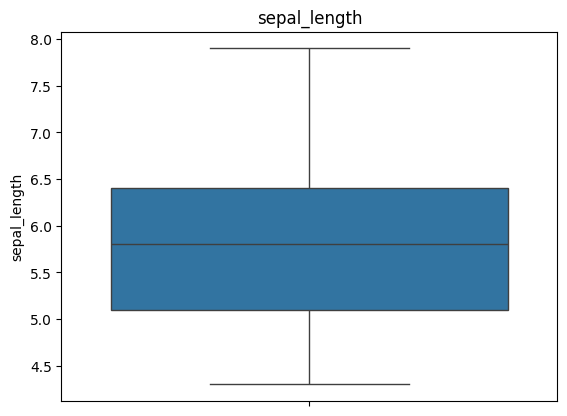

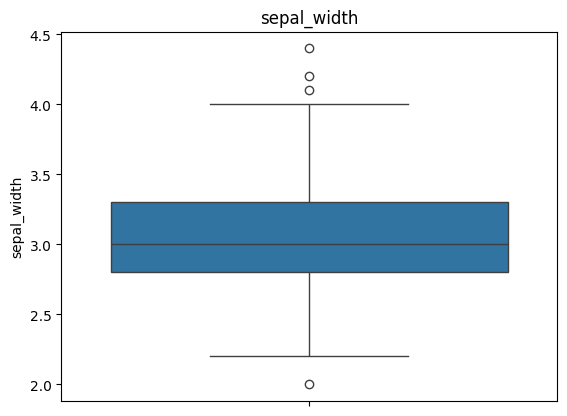

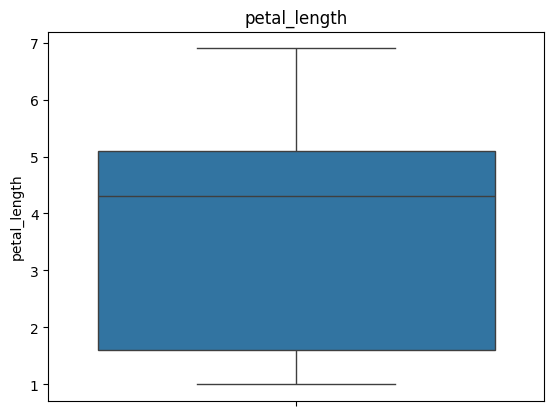

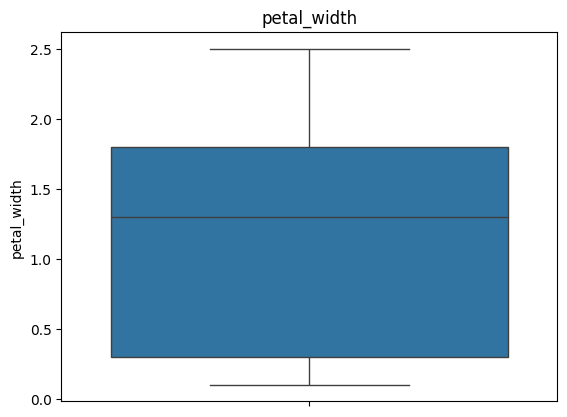

In [8]:
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

## Model Building

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

x = df.drop('species', axis = 1)
y = df['species']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

model = DecisionTreeClassifier(random_state = 42, max_depth = 2, criterion='entropy')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('actual y values : ', y_test.values)
print('predicted y values : ', y_pred)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

actual y values :  ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']
predicted y values :  ['versicolor' 'setosa' 'virginica' 'versicolor' 'virginica' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy   

In [11]:
importance = pd.DataFrame({'feature':x_train.columns, 'importance':model.feature_importances_})
importance.sort_values('importance', ascending = False)

,feature,importance
2,petal_length,1.0
0,sepal_length,0.0
1,sepal_width,0.0
3,petal_width,0.0


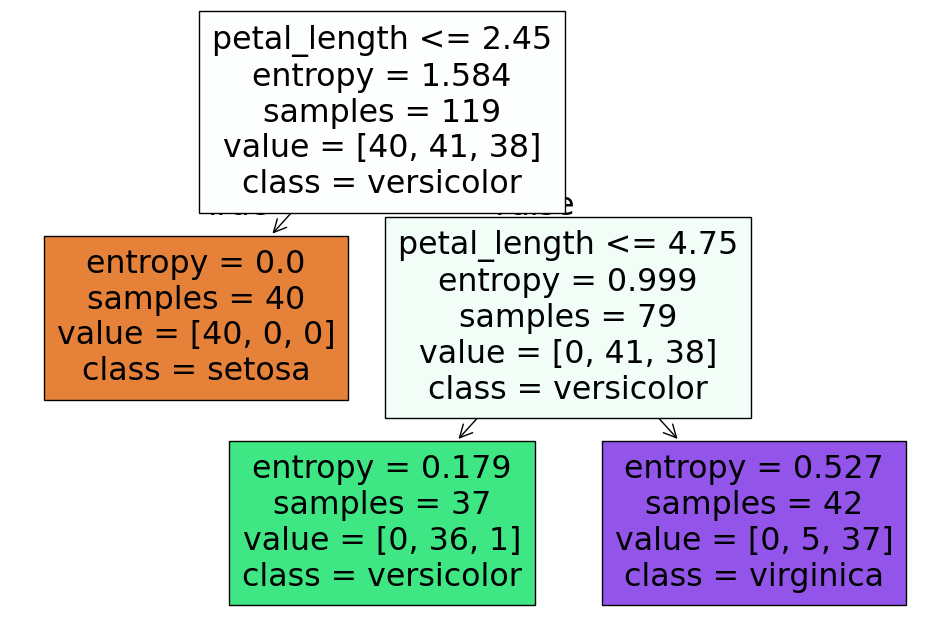

In [17]:
from sklearn.tree import plot_tree
plt.figure(figsize = (12,8))
plot_tree(model, feature_names = x_train.columns, class_names = model.classes_, filled = True)
plt.show()